# Import packages

In [1]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1'

import packages

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import rapids_singlecell as rsc
import scanpy as sc
import seaborn as sns 
from joblib import parallel_backend
import scipy.stats as stats
import seaborn as sns; sns.set(color_codes=True)
import warnings
#import harmonypy
import joblib 
import scanpy.external as sce
import pytometry as pm
import anndata as ad
#import PyComplexHeatmap as pch

<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.Tensor size changed, may indicate binary incompatibility. Expected 64 from C header, got 80 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.NativeFile size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.BufferedInputStream size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.BufferedOutputStream size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.CompressedInputStream size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.CompressedOutputStream size changed, may i

In [7]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1'

In [2]:
projectdir = './celltyping_v2'
#os.mkdir(projectdir)
os.chdir(projectdir)
dir =os.getcwd()
os.listdir()

['stromalcellparams',
 'adjtma_tumour_nontumour.h5ad',
 'adjtma_stromalcells.h5ad',
 'adjtma_cd4.h5ad',
 'adjtma_celltyped_final.h5ad',
 'CT_final.svg',
 'tumour_type.svg',
 'nontumour_sihoette.ipynb',
 'adjtma_nontumour_celltypes.h5ad',
 'tumour_metatypes.svg',
 'adjtma_mac_subtypes.h5ad',
 '.ipynb_checkpoints',
 'adjtma_tumourmeta_types.h5ad',
 'silhouette_batch',
 'tumourmetaparams',
 'cd4params',
 'cd4_silscores.h5ad',
 'adjtma_cd4_subtypes.h5ad',
 'tma_a.csv',
 'adjtma_full.h5ad',
 'tumourcellsparams',
 'qupathout',
 'CD4_types.svg',
 'adata_full.h5ad',
 'tma_b.csv',
 'adjtma_cd8_subtypes.h5ad',
 'adjtma_tumourmeta.h5ad',
 'CD8_types.svg',
 'adjtma_tumour_subtypes.h5ad',
 'tumourmeta_silscores.h5ad',
 'figures',
 'tumourmeta_sihoette.ipynb',
 'CD4_silhouette.ipynb',
 'nontumour_silscores.h5ad',
 'tumour_silscores.h5ad',
 'tumour_type_raw.svg',
 'adjtma_full_backupb.h5ad',
 'tumour_sihoette.ipynb',
 'adjtma_tumourcells.h5ad',
 'tumour_stroma.svg',
 'Connors_TMA_meta.csv']

In [9]:
adata = sc.read('../celltyping/adjtma_start.h5ad')
adata_full = adata
adata_full.write(filename='adjtma_full.h5ad')

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [6]:
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

In [8]:
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity'],
      dtype='object')

# cluster tumour non tumour

In [30]:
tumournontumour = ['CD45','CD3e','CD4', 'CD20', 'cd14','CD68', 'CD8', 'CD34', 'CD31','SMA', 'Vimentin','Ki67','E-cadherin','Pan-Cytokeratin', 'nsize', 'nsolidity', 'ndiameter'] #'Collagen IV','HLA-A','HLA-DR','CD44','CD45RO',

adata = adata[:,adata.var_names.isin(tumournontumour)].copy()
adata.var_names_make_unique()

adata.var_names

Index(['CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8', 'cd14', 'Vimentin', 'CD45',
       'CD34', 'CD3e', 'CD31', 'SMA', 'Ki67', 'Pan-Cytokeratin', 'nsize',
       'nsolidity', 'ndiameter'],
      dtype='object')

In [31]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/8915979/ipykernel_533326/2062090108.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [32]:
sc.tl.pca(adata)
rsc.utils.anndata_to_GPU(adata) # moves `.X` to the GPU
rsc.pp.harmony_integrate (adata, key='Image',max_iter_harmony = 40)
    
adata.obsm['X_pca_d']=adata.obsm['X_pca']
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']

2024-04-19 14:17:35,961 - harmonypy_gpu - INFO - Iteration 1 of 40
2024-04-19 14:17:52,810 - harmonypy_gpu - INFO - Iteration 2 of 40
2024-04-19 14:18:09,804 - harmonypy_gpu - INFO - Iteration 3 of 40
2024-04-19 14:18:26,962 - harmonypy_gpu - INFO - Iteration 4 of 40
2024-04-19 14:18:44,192 - harmonypy_gpu - INFO - Iteration 5 of 40
2024-04-19 14:19:01,336 - harmonypy_gpu - INFO - Iteration 6 of 40
2024-04-19 14:19:18,608 - harmonypy_gpu - INFO - Iteration 7 of 40
2024-04-19 14:19:35,812 - harmonypy_gpu - INFO - Iteration 8 of 40
2024-04-19 14:19:52,996 - harmonypy_gpu - INFO - Iteration 9 of 40
2024-04-19 14:20:03,837 - harmonypy_gpu - INFO - Iteration 10 of 40
2024-04-19 14:20:09,138 - harmonypy_gpu - INFO - Converged after 10 iterations


In [33]:
from pcf_analysis_poetry.phenotyping.phenograph import HybridPhenographModular
 
phenographer = HybridPhenographModular(knn="GPU", refiner="CPU", clusterer="GPU", clustering="leiden")
clusters = phenographer.cluster( adata,
            n_neighbors = 20,
            algorithm="auto",
            metric="euclidean",
            p=2,
            n_jobs=-1,
            two_pass_precision=True,
            resolution=0.4,
            min_size=10) # has most of the same parameters as the cpu phenograph

adata.obs["phenograph_labels"] = clusters[0].get()
adata.obs["phenograph_labels"] = adata.obs["phenograph_labels"].astype('category')
rsc.utils.anndata_to_CPU(adata)


Performing KNN search on GPU: 
	 K = 20
	 Distance Metric = euclidean
	 Search Algorithm = auto

KNN GPU computed in 6.86891770362854 seconds 

Performing Jaccard on CPU: 
	 KNN graph nodes = 1282980
	 KNN graph K-neighbors = 20

Jaccard CPU edgelist constructed in 179.4334089756012seconds 



/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/cugraph/structure/symmetrize.py:93: FutureWarning: Multi is deprecated and the removal of multi edges will no longer be supported from 'symmetrize'. Multi edges will be removed upon creation of graph instance.
  warnings.warn(


Performing Leiden on GPU: 
	 Resolution = 0.4
	 Max iterations = 500
	 Min cluster size = 10

cugraph.leiden computed in 12.945327997207642 seconds 

Q = 0.9040306683090642


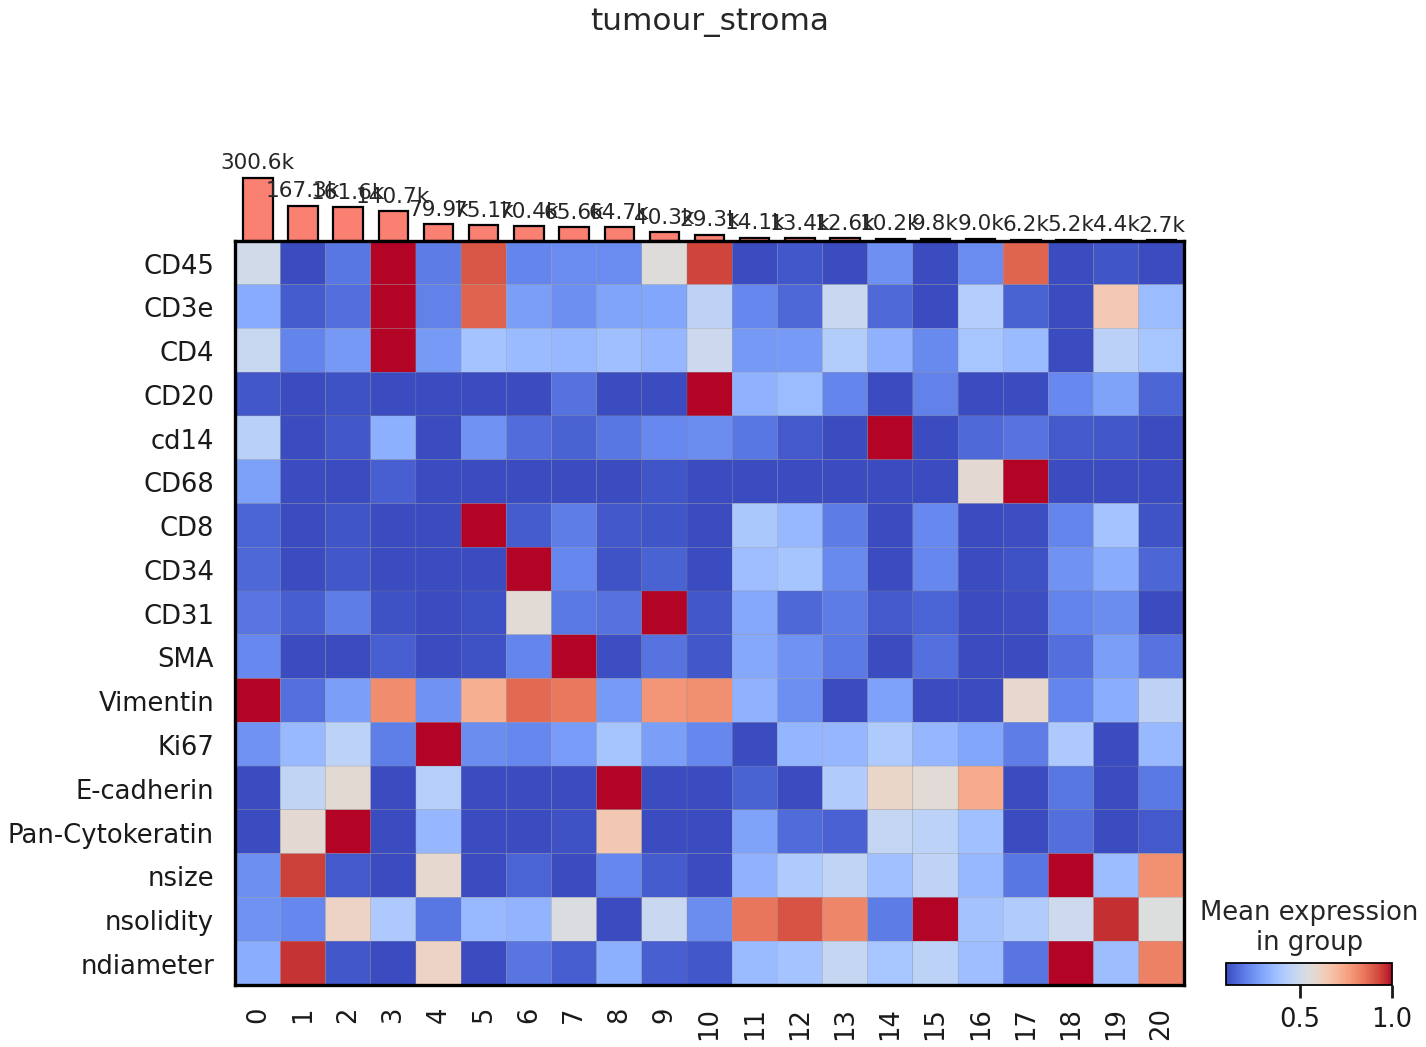

In [34]:
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=400)

sc.pl.matrixplot(adata, var_names= tumournontumour, groupby='phenograph_labels', dendrogram=False,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'tumour_stroma', return_fig=True).add_totals().savefig('tumour_stroma.svg')


In [35]:
tumour_nontumour = {
0: 'Nontumour',
1: 'Tumour',
2: 'Tumour',
3: 'Nontumour',
4: 'Tumour',
5: 'Nontumour',
6: 'Nontumour',
7: 'Nontumour',
8: 'Tumour',
9: 'Nontumour',
10: 'Nontumour',
11: 'Tumour',
12: 'Tumour',
13: 'Tumour',
14: 'Tumour',
15: 'Tumour',
16: 'Tumour',
17: 'Nontumour',
18: 'Tumour',
19: 'Tumour',
20: 'Tumour'}

adata.obs['tumour_nontumour'] = (
    adata.obs['phenograph_labels']
    .map(tumour_nontumour
        )
    .astype('category')
)
adata.write(filename='adjtma_tumour_nontumour.h5ad')

# merge tumour non tumour

In [10]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_tumour_nontumour.h5ad')
adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'tumour_nontumour']], on= 'Object ID', how = 'left')
adata = adata_full
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')
adata.obs.index = adata.obs.index.astype('str')
adata

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 1282980 × 48
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour'
    obsm: 'spatial'

# cluster immune cells

In [ ]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata = adata[adata.obs['tumour_nontumour'].isin(['Nontumour'])].copy()
adata

In [49]:
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

In [50]:
stromalcells = ['CD45','CD3e','CD4', 'CD20', 'cd14','CD68', 'CD8', 'CD34', 'CD31','SMA', 'Vimentin', 'nsolidity', 'ndiameter']
adata = adata[:,adata.var_names.isin(stromalcells)].copy()
adata.var_names

Index(['CD4', 'CD20', 'CD68', 'CD8', 'cd14', 'Vimentin', 'CD45', 'CD34',
       'CD3e', 'CD31', 'SMA', 'nsolidity', 'ndiameter'],
      dtype='object')

In [51]:
adata

AnnData object with n_obs × n_vars = 728167 × 13
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour'
    obsm: 'spatial'

In [52]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/8915979/ipykernel_533326/2062090108.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [53]:
sc.tl.pca(adata)
rsc.utils.anndata_to_GPU(adata) # moves `.X` to the GPU
rsc.pp.harmony_integrate (adata, key='Image',max_iter_harmony = 40)
    
adata.obsm['X_pca_d']=adata.obsm['X_pca']
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']
adata.write('adjtma_stromalcells.h5ad')

2024-04-19 15:09:42,318 - harmonypy_gpu - INFO - Iteration 1 of 40
2024-04-19 15:09:52,934 - harmonypy_gpu - INFO - Iteration 2 of 40
2024-04-19 15:10:03,614 - harmonypy_gpu - INFO - Iteration 3 of 40
2024-04-19 15:10:14,212 - harmonypy_gpu - INFO - Iteration 4 of 40
2024-04-19 15:10:24,824 - harmonypy_gpu - INFO - Iteration 5 of 40
2024-04-19 15:10:35,366 - harmonypy_gpu - INFO - Iteration 6 of 40
2024-04-19 15:10:45,952 - harmonypy_gpu - INFO - Iteration 7 of 40
2024-04-19 15:10:56,487 - harmonypy_gpu - INFO - Iteration 8 of 40
2024-04-19 15:11:07,058 - harmonypy_gpu - INFO - Iteration 9 of 40
2024-04-19 15:11:17,583 - harmonypy_gpu - INFO - Iteration 10 of 40
2024-04-19 15:11:24,777 - harmonypy_gpu - INFO - Iteration 11 of 40
2024-04-19 15:11:28,059 - harmonypy_gpu - INFO - Converged after 11 iterations


In [54]:
adata

AnnData object with n_obs × n_vars = 728167 × 13
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'batch'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1'
    uns: 'pca'
    obsm: 'spatial', 'X_pca', 'X_pca_harmony', 'X_pca_d'
    varm: 'PCs'

In [173]:
dir

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'

In [26]:
adata = ad.read_h5ad(dir + '/stromalcellparams/_pcf_analysis_run/post_phenotype/post_phenosearch.h5ad')
adata1 = ad.read_h5ad('adjtma_stromalcells.h5ad')
adata.obsm['X_pca_harmony'] = adata1.obsm['X_pca_harmony']

In [177]:
phenocols = ['modpheno']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'category'))

def removeq(x):
   x = x.split('_Q0')[0]
   return x
adata.obs.rename(columns=removeq, inplace=True)

def removemod(x):
   x = x.replace('modpheno_','')
   return x
adata.obs.rename(columns=removemod, inplace=True)


In [178]:
best_ps = (list(adata.obs.filter(like = 'K', axis=1 )))
#best_ps

In [ ]:
# run on bunya
scorename='nontumour_silscores'
import cuml
X = adata.X
scores={}
for pix, p in enumerate(best_ps):
    y = adata.obs[p] # Replace this with the pheno labels;
    score = cuml.metrics.cluster.silhouette_score(X=adata.X, labels=y)
    scores[p]=score   
    
scores= pd.DataFrame.from_dict(scores, orient='index')
scores.reset_index(drop=False, inplace=True)
scores.columns = scores.columns.astype('str')
adata.uns[scorename] = scores

In [ ]:
adata.write(scorename + '_adata.h5ad')

In [6]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'

In [8]:
scorename='nontumour_silscores'
adata = ad.read_h5ad('nontumour_silscores.h5ad')

In [9]:
len(adata.uns[scorename])

40

In [10]:
adata

AnnData object with n_obs × n_vars = 728167 × 13
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'batch', 'K15_R0.1', 'K15_R0.2', 'K15_R0.3', 'K15_R0.4', 'K20_R0.1', 'K20_R0.2', 'K20_R0.3', 'K20_R0.4', 'K25_R0.1', 'K25_R0.2', 'K25_R0.3', 'K25_R0.4', 'K30_R0.1', 'K30_R0.2', 'K30_R0.3', 'K30_R0.4', 'K35_R0.1', 'K35_R0.2', 'K35_R0.3', 'K35_R0.4', 'K40_R0.1', 'K40_R0.2', 'K40_R0.3', 'K40_R0.4', 'K45_R0.1', 'K45_R0.2', 'K45_R0.3', 'K45_R0.4', 'K50_R0.1', 'K50_R0.2', 'K50_R0.3', 'K50_R0.4', 'K55_R0.1', 'K55_R0.2', 'K55_R0.3', 'K55_R0.4', 'K60_R0.1', 'K60_R0.2', 'K60_R0.3', 'K60_R0.4'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1'
    uns: 'nontumour_silscores', 'param_grid', 'pca'
    obsm: 'X_pca', 'X_pca_d', 'X_pca_harmony', 'spatial'
    varm: 'PCs'

In [11]:
silscores = list(adata.uns[scorename].sort_values(by='0')[34:41]['index'])

In [12]:
list(adata.uns[scorename].sort_values(by='0')[34:41]['index'])

['K50_R0.2', 'K45_R0.2', 'K35_R0.1', 'K25_R0.3', 'K25_R0.1', 'K40_R0.2']

In [13]:
adata.uns[scorename].sort_values(by='0')[34:41]

,index,0
29,K50_R0.2,0.113223
25,K45_R0.2,0.113418
16,K35_R0.1,0.115563
10,K25_R0.3,0.115717
8,K25_R0.1,0.117700
21,K40_R0.2,0.122082


In [ ]:
stromalcells = ['CD45','CD3e','CD4', 'CD20', 'cd14','CD68', 'CD8', 'CD34', 'CD31','SMA', 'Vimentin', 'nsolidity', 'ndiameter']


rsc.utils.anndata_to_CPU(adata) # moves `.X` to the GPU

for vs,v in enumerate(silscores):
    sc.pl.matrixplot(adata, var_names= stromalcells, groupby=v, dendrogram=False,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = f"{v}", return_fig=True).add_totals().savefig(f"figures/matrixplot_{v}_nontumour.png")


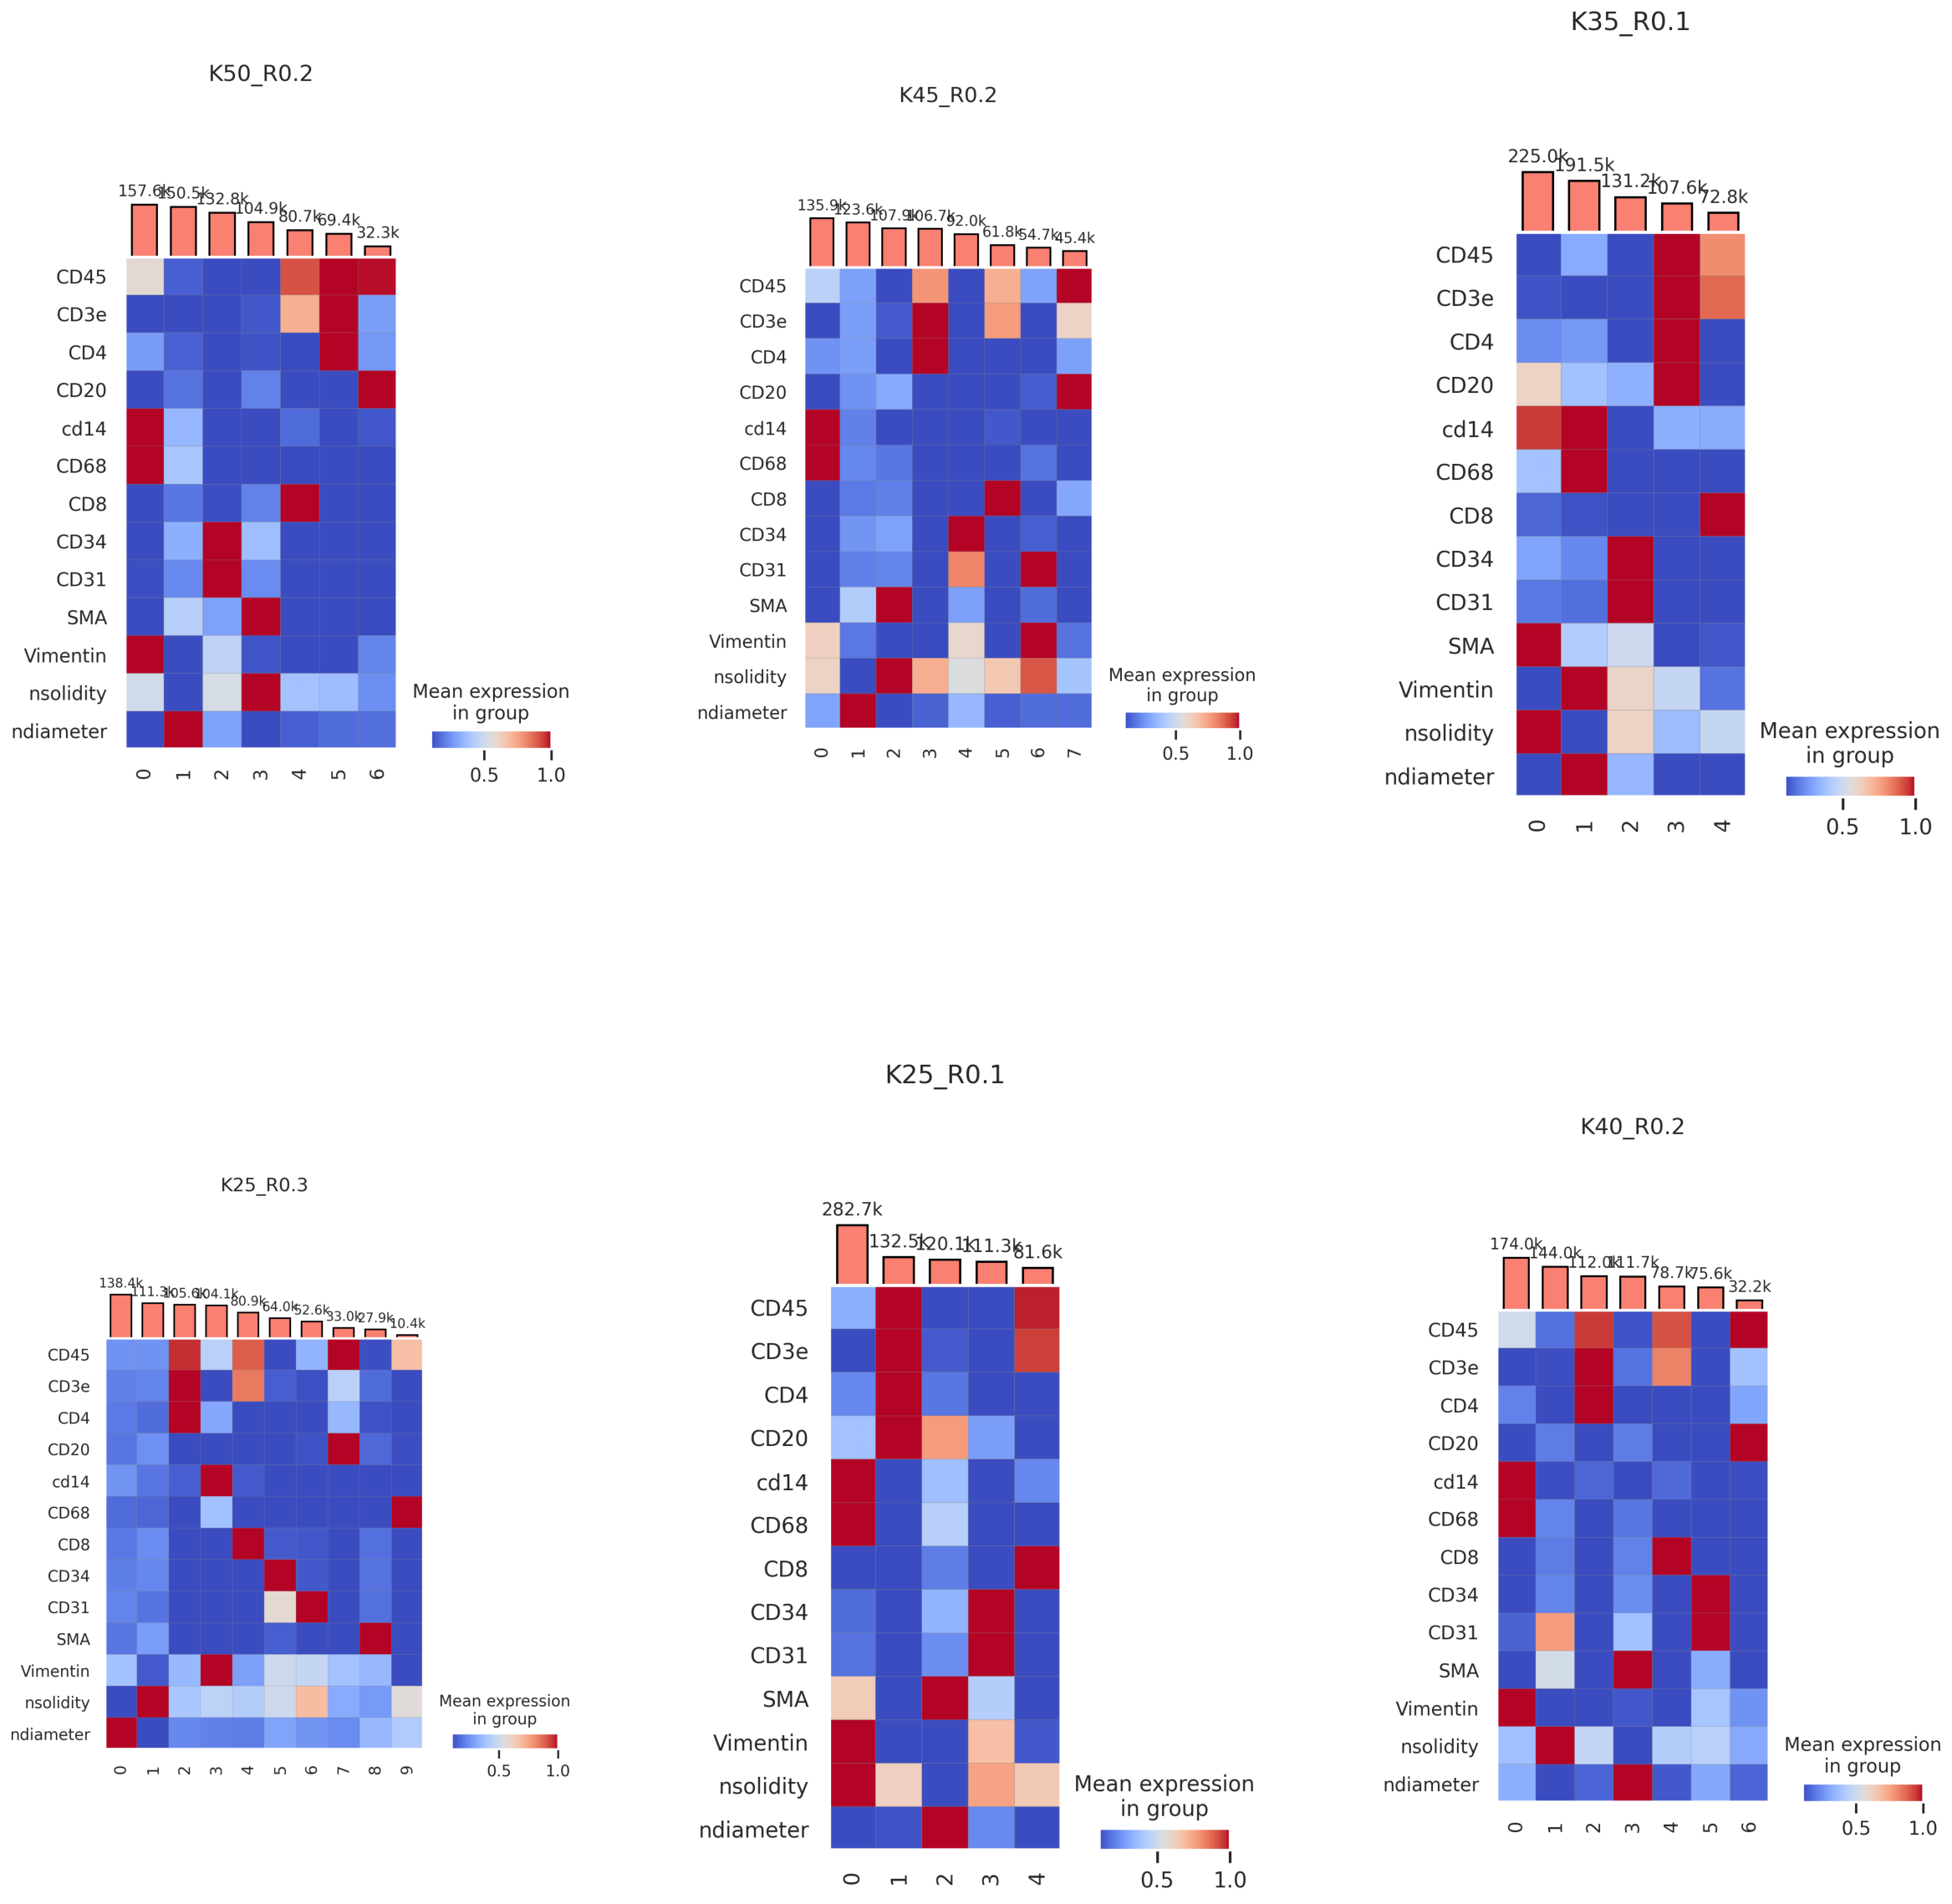

In [15]:
images = [plt.imread(f"./figures/matrixplot_{mp}_nontumour.png") for mp in silscores]

fig, axes = plt.subplots(2, 3, sharex=False, sharey=False, figsize=(30, 30)) 

for img, ax in zip(images, axes.flat):
    ax.imshow(img)
    ax.axis('off')

Select score with best performance: K40 R0.2

In [18]:
nontumourcelltypes = {
0: 'Macrophages',
1: 'Other_Stromal_cells',
2: 'CD4_cells',
3: 'Fibroblast',
4: 'CD8_cells',
5: 'Vessels',
6: 'B_cells'}

adata.obs['immunecelltypes'] = (
    adata.obs['K40_R0.2']
    .map(nontumourcelltypes
        )
    .astype('category')
)
adata.write(filename='adjtma_nontumour_celltypes.h5ad')

In [4]:
adata = ad.read_h5ad('adjtma_nontumour_celltypes.h5ad')

In [7]:
adata.var_names

Index(['CD4', 'CD20', 'CD68', 'CD8', 'cd14', 'Vimentin', 'CD45', 'CD34',
       'CD3e', 'CD31', 'SMA', 'nsolidity', 'ndiameter'],
      dtype='object')

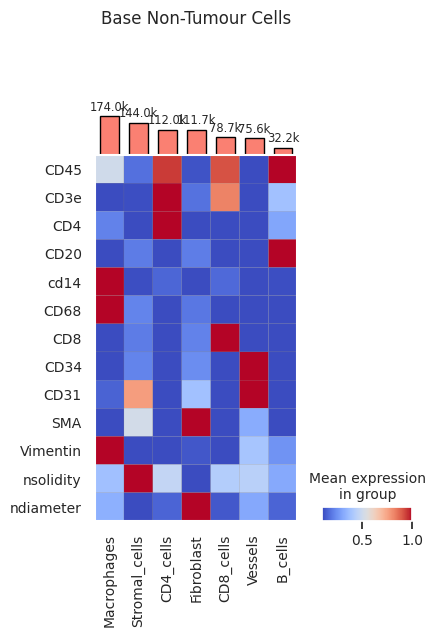

In [5]:
stromalcells = ['CD45','CD3e','CD4', 'CD20', 'cd14','CD68', 'CD8', 'CD34', 'CD31','SMA', 'Vimentin', 'nsolidity', 'ndiameter']
sc.pl.matrixplot(adata, var_names= stromalcells, groupby='immunecelltypes', dendrogram=False,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'Base Non-Tumour Cells', return_fig=True).add_totals().savefig('./figures/non_tumour_basecells.svg')

# merge immune cells

In [11]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_nontumour_celltypes.h5ad')
adata.obs.replace({'immunecelltypes': {'Stromal_cells':'Other_Stromal_cells'}}, inplace=True)
adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'immunecelltypes']], on= 'Object ID', how = 'left')
adata = adata_full
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')


/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [6]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'

# subset CD4

In [105]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata = adata[adata.obs['immunecelltypes'].isin(['CD4_cells'])].copy()
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

In [106]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/9494858/ipykernel_764875/2062090108.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [107]:
obs_df = sc.get.obs_df(adata, keys=adata.var_names.tolist())
#sns.kdeplot(data=obs_df[adata.var_names[0]])

In [108]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture 
def binary_gmm(adata, var, plot=False):  
    data = sc.get.obs_df(adata, [var])
    gmm = GaussianMixture(2)
    gmm.fit(data)
    # Get means of the components
    means = gmm.means_.flatten()
    # Sort components based on means
    order = np.argsort(means)
    # Assign labels based on the order of means
    sorted_labels = np.zeros_like(gmm.predict(data))
    sorted_labels[gmm.predict(data) == order[1]] = 1
    adata.obs[f"{var}_pos"] = sorted_labels
    data["y_pred"] = sorted_labels
    
    if plot:
        sns.kdeplot(data, x=var, color="black", cut=0)#, log_scale=10
        sns.kdeplot(data, x=var, hue="y_pred", cut=0)#, log_scale=10
        

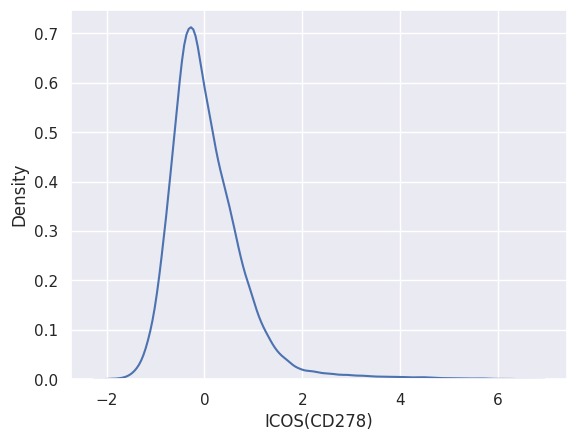

In [109]:
sns.kdeplot(data=obs_df['ICOS(CD278)'])
plt.savefig('./figures/cd4_icos.svg')

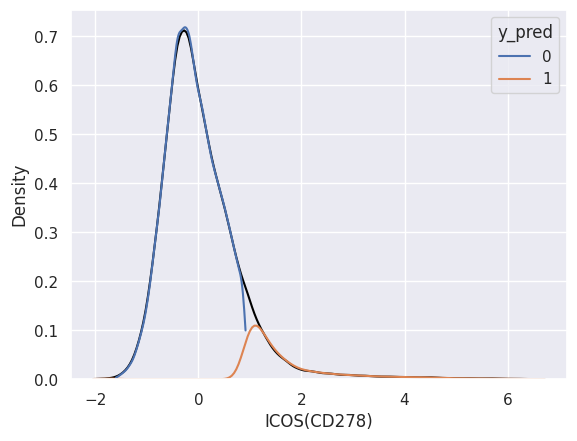

In [110]:
binary_gmm(adata, 'ICOS(CD278)', plot=True)
plt.savefig('./figures/cd4_icos_gmm.svg')

In [15]:
binary_gmm(adata, adata.var_names[2], plot=False)

In [16]:
adata

AnnData object with n_obs × n_vars = 112022 × 3
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'batch', 'ICOS(CD278)_pos', 'FOXP3_pos', 'PD-1_pos'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1'
    obsm: 'spatial'

In [17]:
rmap = {'ICOS(CD278)_pos': {0:float('nan'), 1:'ICOS+'}, 'FOXP3_pos': {0:float('nan'),1:'FOXP3+'},'PD-1_pos':{0:float('nan'), 1:'PD1+'}}
adata.obs.replace(rmap, inplace=True)


In [18]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'string'))

adata.obs['CD4_type'] = adata.obs[['immunecelltypes','ICOS(CD278)_pos', 'FOXP3_pos', 'PD-1_pos']].fillna('').agg('_'.join, axis=1)

In [19]:
adata.obs['CD4_type']= adata.obs['CD4_type'].str.replace('__','')
adata.obs['CD4_type']= adata.obs['CD4_type'].str.replace('___','')
adata.obs['CD4_type']= adata.obs['CD4_type'].str.replace('____','')
adata.obs['CD4_type'].value_counts()

CD4_cells_                     105186
CD4_cells_ICOS+                  3175
CD4_cells_PD1+                   2045
CD4_cellsFOXP3+_                  582
CD4_cells_ICOS+_FOXP3+_           394
CD4_cells_ICOS+PD1+               299
CD4_cellsFOXP3+_PD1+              261
CD4_cells_ICOS+_FOXP3+_PD1+        80
Name: CD4_type, dtype: int64

In [20]:
#drop Tregs - FOXP3 too high background

rmap = {'CD4_type': {'CD4_cellsFOXP3+_': 'CD4_cells', 'CD4_cellsFOXP3+_PD1+':'CD4_cells', 
                     'CD4_cells_ICOS+_FOXP3+_':'CD4_TFH','CD4_cells_':'CD4_cells',
                     'CD4_cells_ICOS+':'CD4_TFH','CD4_cells_ICOS+PD1+':'CD4_TFH',
                     'CD4_cells_ICOS+_FOXP3+_PD1+':'CD4_TFH', 'CD4_cells_PD1+':'CD4_TFH'}}
adata.obs.replace(rmap, inplace=True)


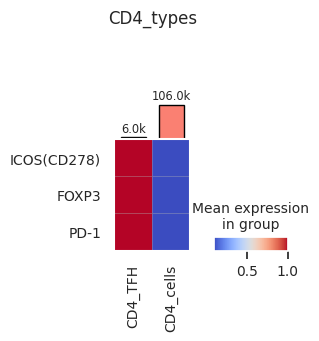

In [21]:
sc.pl.matrixplot(adata, var_names= cd4_func, groupby='CD4_type', dendrogram=False,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'CD4_types', return_fig=True).add_totals().savefig('CD4_types.svg')

In [22]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'object'))

In [23]:
adata.write('adjtma_cd4_subtypes.h5ad')

In [68]:
adata = ad.read_h5ad('adjtma_cd4_subtypes.h5ad') 
set(adata.obs.CD4_type)

{'CD4_TFH', 'CD4_cells', 'Treg'}

In [69]:
adata.obs['CD4_type'].value_counts()

CD4_cells    106095
CD4_TFH        5084
Treg            843
Name: CD4_type, dtype: int64

In [70]:
adata.write('adjtma_cd4_subtypes.h5ad')

# merge CD4 types

In [12]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_cd4_subtypes.h5ad')
adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'CD4_type']], on= 'Object ID', how = 'left')
adata = adata_full
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')


/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [54]:
scorename='cd4_silscores'
adata = ad.read_h5ad('cd4_silscores.h5ad')
adata

AnnData object with n_obs × n_vars = 112022 × 7
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'Tumour_type', 'tumour_metatypes', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'Stage', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking hx ', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse?', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'immunecelltypes', 'batch', 'K15_R0.1', 'K15_R0.2', 'K15_R0.3', 'K15_R0.4', 'K20_R0.1', 'K20_R0.2', 'K20_R0.3', 'K20_R0.4', 'K25_R0.1', 'K25_R0.2', 'K25_R0.3', 'K25_R0.4', 'K30_R0.1', 'K30_R0.2', 'K30_R0.3', 'K30_R0.4', 'K35_R0.1', 'K35_R0.2', 'K35_R0.3', 'K35_R0.4', 'K40_R0.1', 'K40_R0.2', 'K40_R0.3', 'K40_R0.4', 'K45_R0.1', '

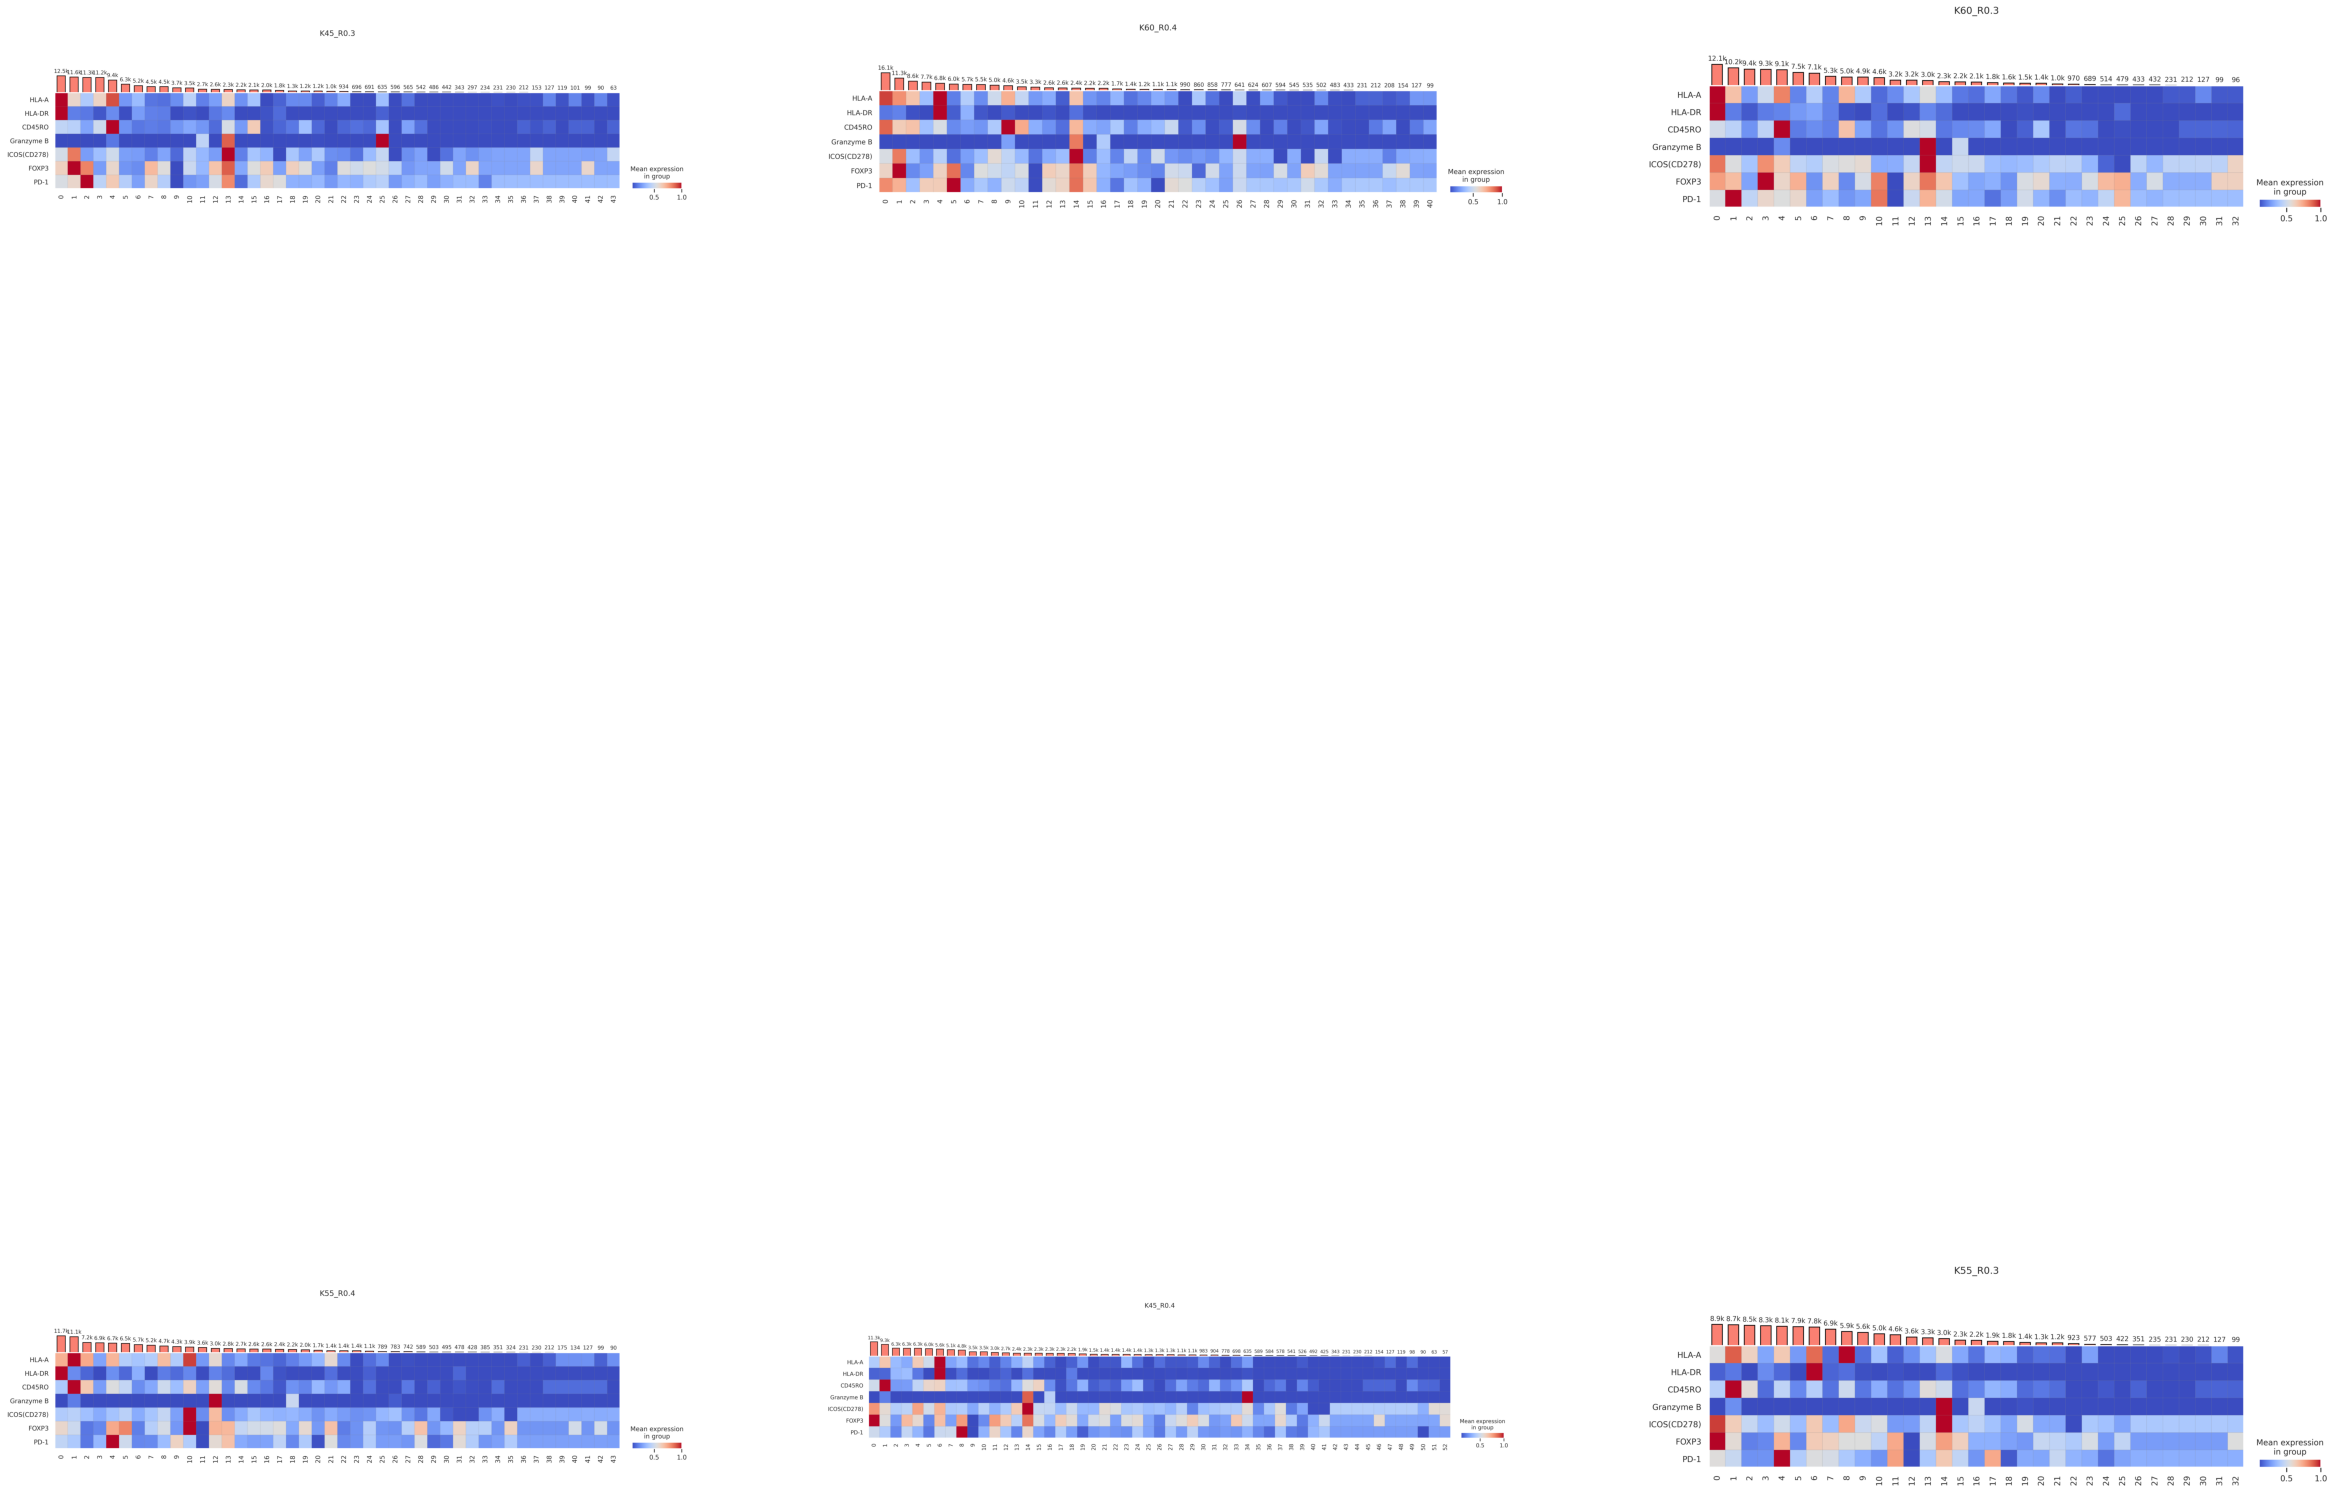

In [55]:
scorename='cd4_silscores'
silscores = list(adata.uns[scorename].sort_values(by='0')[34:41]['index'])
images = [plt.imread(f"./figures/matrixplot_{mp}_cd4.png") for mp in silscores]

fig, axes = plt.subplots(2, 3, sharex=False, sharey=False, figsize=(30, 30)) 

for img, ax in zip(images, axes.flat):
    ax.imshow(img)
    ax.axis('off')

# subset CD8

In [94]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata = adata[adata.obs['immunecelltypes'].isin(['CD8_cells'])].copy()
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

In [95]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/9494858/ipykernel_764875/2062090108.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [97]:
obs_df = sc.get.obs_df(adata, keys=adata.var_names.tolist())
#sns.kdeplot(data=obs_df[adata.var_names[0]])

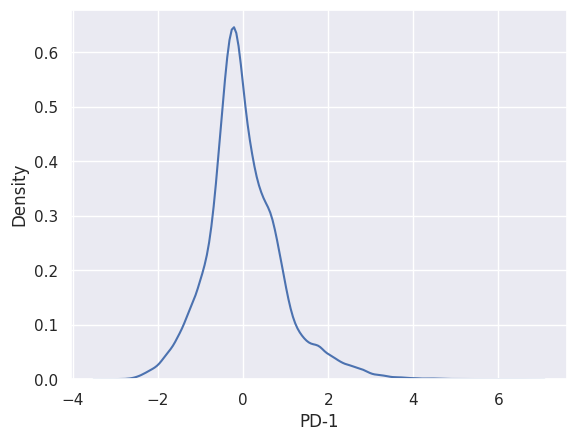

In [98]:
sns.kdeplot(data=obs_df['PD-1'])
plt.savefig('./figures/cd8_pd1.svg')

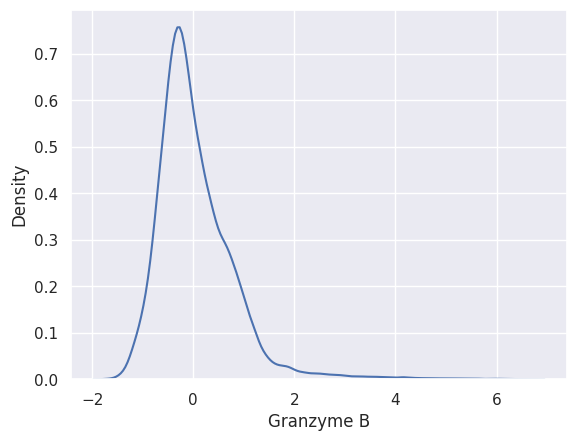

In [99]:
sns.kdeplot(data=obs_df['Granzyme B'])
plt.savefig('./figures/cd8_gzmb.svg')

In [81]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture 
def binary_gmm(adata, var, plot=False):  
    data = sc.get.obs_df(adata, [var])
    gmm = GaussianMixture(2)
    gmm.fit(data)
    # Get means of the components
    means = gmm.means_.flatten()
    # Sort components based on means
    order = np.argsort(means)
    # Assign labels based on the order of means
    sorted_labels = np.zeros_like(gmm.predict(data))
    sorted_labels[gmm.predict(data) == order[1]] = 1
    adata.obs[f"{var}_pos"] = sorted_labels
    data["y_pred"] = sorted_labels
    
    if plot:
        sns.kdeplot(data, x=var, color="black", cut=0).get_figure()#, log_scale=10
        sns.kdeplot(data, x=var, hue="y_pred", cut=0).get_figure()#, log_scale=10
        

In [103]:
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

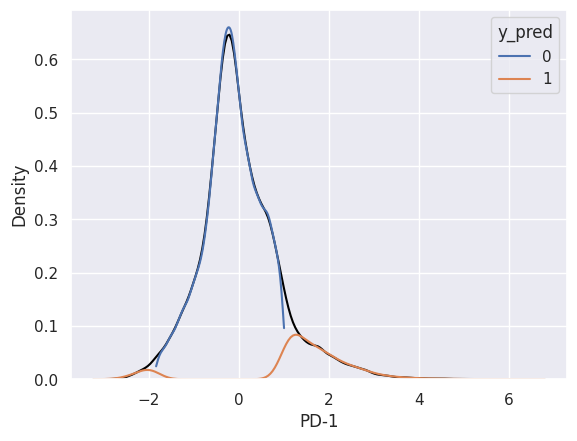

In [101]:
binary_gmm(adata, 'PD-1', plot=True)
plt.savefig('./figures/cd8_pd1_gmm.svg')

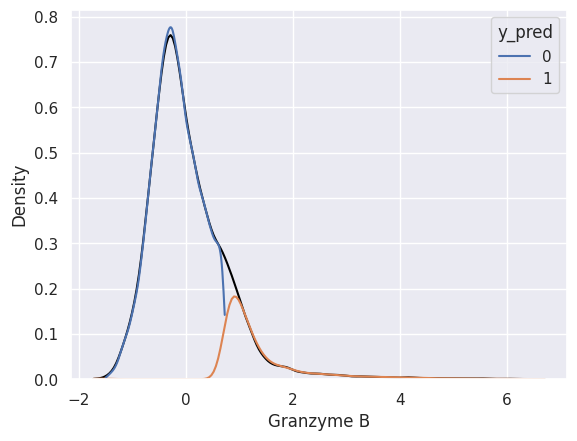

In [102]:
binary_gmm(adata, 'Granzyme B', plot=True)
plt.savefig('./figures/cd8_gzmb_gmm.svg')

In [72]:
adata

AnnData object with n_obs × n_vars = 78729 × 2
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'Tumour_type', 'tumour_metatypes', 'CD4_type', 'batch', 'Granzyme B_pos', 'PD-1_pos'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1'
    obsm: 'spatial'

In [73]:
rmap = {'Granzyme B_pos': {0:float('nan'), 1:'GZMB+'}, 'PD-1_pos':{0:float('nan'), 1:'PD1+'}}
adata.obs.replace(rmap, inplace=True)


In [74]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'string'))

adata.obs['CD8_type'] = adata.obs[['immunecelltypes','Granzyme B_pos', 'PD-1_pos']].fillna('').agg('_'.join, axis=1)

In [78]:
adata.obs['CD8_type']= adata.obs['CD8_type'].str.replace('__','')
adata.obs['CD8_type']= adata.obs['CD8_type'].str.replace('___','')
adata.obs['CD8_type']= adata.obs['CD8_type'].str.replace('____','')
adata.obs['CD8_type'].value_counts()

CD8_cells               69537
CD8_cellsPD1+            4633
CD8_cells_GZMB+_         3625
CD8_cells_GZMB+_PD1+      934
Name: CD8_type, dtype: int64

In [77]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'object'))

In [ ]:
set(adata.obs['CD8_type'])

In [80]:
rmap = {'CD8_type': {'CD8_cells': 'CD8_cells', 'CD8_cellsPD1+':'PD1+_CD8_cells', 'CD8_cells_GZMB+_':'Cytotoxic_CD8_cells',
                    'CD8_cells_GZMB+_PD1+':'PD1+_CD8_cells'}}
adata.obs.replace(rmap, inplace=True)


In [81]:
set(adata.obs.CD8_type)

{'CD8_cells', 'Cytotoxic_CD8_cells', 'PD1+_CD8_cells'}

In [83]:
adata.obs['CD8_type'].value_counts()

CD8_cells              69537
PD1+_CD8_cells          5567
Cytotoxic_CD8_cells     3625
Name: CD8_type, dtype: int64

In [84]:
adata.write('adjtma_cd8_subtypes.h5ad')

# merge CD8 types

In [13]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_cd8_subtypes.h5ad')
adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'CD8_type']], on= 'Object ID', how = 'left')
adata = adata_full
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')


/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


# subset Macrophage

In [99]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata = adata[adata.obs['immunecelltypes'].isin(['Macrophages'])].copy()
adata.var_names

Index(['DAPI', 'CD45RO', 'HLA-A', 'CD4', 'E-cadherin', 'CD20', 'CD68', 'CD8',
       'cd14', 'CD11c', 'CD44', 'Vimentin', 'CD45', 'Granzyme B', 'CD34',
       'CD3e', 'LAG3', 'CD31', 'PD-L1', 'ICOS(CD278)', 'NAKATPASE', 'FOXP3',
       'CD19', 'CD163', 'PAX5', 'G6PD', 'PD-1', 'CD21', 'SMA', 'CD11B', 'CD57',
       'HLA-DR', 'pNRF2', 'LDHA', 'ATPA5', 'Collagen IV', 'GLUT1',
       'Hexokinase1', 'ASCT2', 'CITRATE SYNTHASE', 'SDHA', 'IDH2', 'Ki67',
       'Pan-Cytokeratin', 'CPT1A', 'nsize', 'nsolidity', 'ndiameter'],
      dtype='object')

In [101]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/9040270/ipykernel_1872336/205518848.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [102]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture 
def binary_gmm(adata, var, plot=False):  
    data = sc.get.obs_df(adata, [var])
    gmm = GaussianMixture(2)
    gmm.fit(data)
    # Get means of the components
    means = gmm.means_.flatten()
    # Sort components based on means
    order = np.argsort(means)
    # Assign labels based on the order of means
    sorted_labels = np.zeros_like(gmm.predict(data))
    sorted_labels[gmm.predict(data) == order[1]] = 1
    adata.obs[f"{var}_pos"] = sorted_labels
    data["y_pred"] = sorted_labels
    
    if plot:
        sns.kdeplot(data, x=var, color="black", cut=0)#, log_scale=10
        sns.kdeplot(data, x=var, hue="y_pred", cut=0)#, log_scale=10
        

In [ ]:
binary_gmm(adata, 'CD163', plot=True)
binary_gmm(adata, 'PD-L1', plot=True)

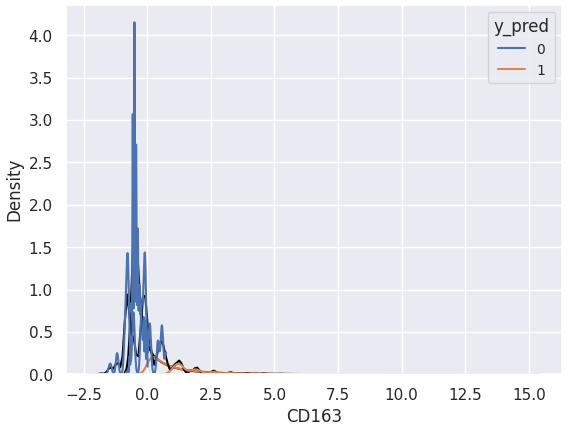

In [103]:
# Fit a positive/negative GMM to each functional marker; Predict MLE
for v in mac_func:
    binary_gmm(adata, v, plot=True)
adata.layers["marker_pos_mask"] = adata.obs.filter(regex=r"_pos$") # Add as an X layer

In [104]:
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes',
       'Tumour_type', 'tumour_metatypes', 'CD4_type', 'CD8_type', 'batch',
       'CD163_pos', 'PD-L1_pos'],
      dtype='object')

In [105]:
rmap = {'CD163_pos': {0:float('nan'), 1:'M2_mac'}, 'PD-L1_pos': {0:float('nan'),1:'PDL1+'}}
adata.obs.replace(rmap, inplace=True)


In [106]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'string'))

adata.obs['mac_type'] = adata.obs[['immunecelltypes','CD163_pos', 'PD-L1_pos']].fillna('').agg('_'.join, axis=1)

In [107]:
adata.obs['mac_type']= adata.obs['mac_type'].str.replace('__','')
adata.obs['mac_type']= adata.obs['mac_type'].str.replace('___','')
adata.obs['mac_type']= adata.obs['mac_type'].str.replace('____','')
adata.obs['mac_type'].value_counts()

Macrophages                 115350
Macrophages_M2_mac_          36381
MacrophagesPDL1+             12398
Macrophages_M2_mac_PDL1+      9826
Name: mac_type, dtype: int64

In [109]:
rmap = {'mac_type': {'Macrophages': 'Macrophages', 'MacrophagesPDL1+':'Macrophages_PDL1+', 'Macrophages_M2_mac_':'Macrophages_M2',
                    'Macrophages_M2_mac_PDL1+':'Macrophages_M2_PDL1+'}}
adata.obs.replace(rmap, inplace=True)

In [110]:
set(adata.obs.mac_type)

{'Macrophages', 'Macrophages_M2', 'Macrophages_M2_PDL1+', 'Macrophages_PDL1+'}

In [111]:
adata.obs['mac_type'].value_counts()

Macrophages             115350
Macrophages_M2           36381
Macrophages_PDL1+        12398
Macrophages_M2_PDL1+      9826
Name: mac_type, dtype: int64

In [112]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'object'))

In [113]:
adata.write('adjtma_mac_subtypes.h5ad')

# merge mac types

In [14]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_mac_subtypes.h5ad')
adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'mac_type']], on= 'Object ID', how = 'left')
adata = adata_full
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')


/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


# treshold tumour

In [14]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata = adata[adata.obs['tumour_nontumour'].isin(['Tumour'])].copy()
adata

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 554813 × 48
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'Tumour_type'
    obsm: 'spatial'

In [15]:
tumourcells= ['CD44', 'PD-L1', 'Ki67','HLA-A','HLA-DR']
adata = adata[:,adata.var_names.isin(tumourcells)].copy()
adata.var_names

Index(['HLA-A', 'CD44', 'PD-L1', 'HLA-DR', 'Ki67'], dtype='object')

In [16]:
def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

#adata1.X = stats.zscore(adata1.X,axis=1)
#adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

/scratch/temp/9040270/ipykernel_1872336/205518848.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


In [17]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture 
def binary_gmm(adata, var, plot=False):  
    data = sc.get.obs_df(adata, [var])
    gmm = GaussianMixture(2)
    gmm.fit(data)
    # Get means of the components
    means = gmm.means_.flatten()
    # Sort components based on means
    order = np.argsort(means)
    # Assign labels based on the order of means
    sorted_labels = np.zeros_like(gmm.predict(data))
    sorted_labels[gmm.predict(data) == order[1]] = 1
    adata.obs[f"{var}_pos"] = sorted_labels
    data["y_pred"] = sorted_labels
    
    if plot:
        sns.kdeplot(data, x=var, color="black", cut=0)#, log_scale=10
        sns.kdeplot(data, x=var, hue="y_pred", cut=0)#, log_scale=10
        

In [18]:
# Fit a positive/negative GMM to each functional marker; Predict MLE
for v in tumourcells:
    binary_gmm(adata, v, plot=False)
adata.layers["marker_pos_mask"] = adata.obs.filter(regex=r"_pos$") # Add as an X layer

In [19]:
rmap = {'CD44_pos': {0:float('nan'), 1:'CD44+'}, 'PD-L1_pos': {0:float('nan'),1:'PDL1+'},'Ki67_pos':{0:float('nan'), 1:'Ki67+'}, 
                     'HLA-A_pos': {0:float('nan'),1:'HLA_A+'},'HLA-DR_pos':{0:float('nan'), 1:'HLADR+'}}
adata.obs.replace(rmap, inplace=True)

In [20]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'string'))

adata.obs['Tumour_type'] = adata.obs[['tumour_nontumour','CD44_pos', 'PD-L1_pos', 'Ki67_pos', 'HLA-A_pos', 'HLA-DR_pos']].fillna('').agg('_'.join, axis=1)

In [21]:
adata.obs['Tumour_type']= adata.obs['Tumour_type'].str.replace('__','')
adata.obs['Tumour_type']= adata.obs['Tumour_type'].str.replace('___','')
adata.obs['Tumour_type']= adata.obs['Tumour_type'].str.replace('____','')
adata.obs['Tumour_type'].value_counts()

Tumour_                                   251681
Tumour_CD44+                               61476
Tumour_HLADR+                              51984
Tumour_Ki67+                               31812
TumourHLA_A+_                              27175
Tumour_CD44+HLADR+                         23501
TumourHLA_A+_HLADR+                        13408
Tumour_CD44+_HLA_A+_                       13280
TumourPDL1+_                               10424
Tumour_CD44+_PDL1+_                         9770
Tumour_CD44+Ki67+                           8313
Tumour_CD44+_HLA_A+_HLADR+                  7655
TumourPDL1+HLA_A+_                          5836
Tumour_Ki67+_HLA_A+_                        5621
TumourPDL1+HLA_A+_HLADR+                    5475
Tumour_CD44+_PDL1+HLA_A+_HLADR+             4118
Tumour_CD44+_PDL1+HLA_A+_                   3534
Tumour_CD44+_PDL1+_Ki67+                    2927
Tumour_CD44+Ki67+_HLA_A+_                   2707
Tumour_CD44+_PDL1+_Ki67+_HLA_A+_            1890
Tumour_Ki67+HLADR+  

In [ ]:
adata.obs['Tumour_type_tidy'] = adata.obs['Tumour_type']
rmap = {'Tumour_type_tidy': {'Tumour_': 'Tumour',
'Tumour_CD44+': 'CD44+',
'Tumour_HLADR+': 'MHC_II',
'Tumour_Ki67+': 'Proliferating',
'TumourHLA_A+_': 'MHC_I',
'Tumour_CD44+HLADR+': 'MHC_II_CD44+',
'TumourHLA_A+_HLADR+': 'MHC_I&II',
'Tumour_CD44+_HLA_A+_': 'MHC_I_CD44+',
'TumourPDL1+_': 'PDL1+',
'Tumour_CD44+_PDL1+_': 'CD44+_PDL1+',
'Tumour_CD44+Ki67+': 'Proliferating_CD44+',
'Tumour_CD44+_HLA_A+_HLADR+': 'MHC_I&II_CD44+',
'TumourPDL1+HLA_A+_': 'PDL1_MHC_I',
'Tumour_Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'TumourPDL1+HLA_A+_HLADR+': 'PDL1_MHC_I&II',
'Tumour_CD44+_PDL1+HLA_A+_HLADR+': 'PDL1_MHC_I&II_CD44+',
'Tumour_CD44+_PDL1+HLA_A+_': 'PDL1_MHC_I_CD44+',
'Tumour_CD44+_PDL1+_Ki67+': 'Proliferating_PDL1',
'Tumour_CD44+Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'Tumour_CD44+_PDL1+_Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'Tumour_Ki67+HLADR+': 'Proliferating_MHC_II',
'Tumour_CD44+_PDL1+_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'TumourPDL1+_Ki67+': 'Proliferating_PDL1',
'TumourPDL1+_Ki67+_HLA_A+_': 'Proliferating_PDL1',
'TumourPDL1+_HLADR+': 'PDL1_MHC_II',
'Tumour_CD44+_PDL1+_HLADR+': 'PDL1_MHC_II',
'Tumour_CD44+Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'Tumour_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'Tumour_CD44+Ki67+HLADR+': 'Proliferating_MHC_II',
'TumourPDL1+_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'TumourPDL1+_Ki67+HLADR+': 'Proliferating_MHC_II',
'Tumour_CD44+_PDL1+_Ki67+HLADR+': 'Proliferating_MHC_II'
}}

adata.obs.replace(rmap, inplace=True)

In [ ]:
set(adata.obs['Tumour_type_tidy'])

In [22]:
phenocols = ['_pos']
adata.obs = adata.obs.astype(
    dict.fromkeys(adata.obs.columns[adata.obs.columns.str.contains('|'.join(phenocols))], 'object'))

In [23]:
adata.write('adjtma_tumour_subtypes.h5ad')

# merge tumour func

In [15]:
adata_full = ad.read_h5ad('adjtma_full.h5ad')
adata = ad.read_h5ad('adjtma_tumour_subtypes.h5ad')

In [16]:
adata.obs['Tumour_type_tidy'] = adata.obs['Tumour_type']
rmap = {'Tumour_type_tidy': {'Tumour_': 'Tumour',
'Tumour_CD44+': 'CD44+',
'Tumour_HLADR+': 'MHC_II',
'Tumour_Ki67+': 'Proliferating',
'TumourHLA_A+_': 'MHC_I',
'Tumour_CD44+HLADR+': 'MHC_II_CD44+',
'TumourHLA_A+_HLADR+': 'MHC_I&II',
'Tumour_CD44+_HLA_A+_': 'MHC_I_CD44+',
'TumourPDL1+_': 'PDL1+',
'Tumour_CD44+_PDL1+_': 'CD44+_PDL1+',
'Tumour_CD44+Ki67+': 'Proliferating_CD44+',
'Tumour_CD44+_HLA_A+_HLADR+': 'MHC_I&II_CD44+',
'TumourPDL1+HLA_A+_': 'PDL1_MHC_I',
'Tumour_Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'TumourPDL1+HLA_A+_HLADR+': 'PDL1_MHC_I&II',
'Tumour_CD44+_PDL1+HLA_A+_HLADR+': 'PDL1_MHC_I&II_CD44+',
'Tumour_CD44+_PDL1+HLA_A+_': 'PDL1_MHC_I_CD44+',
'Tumour_CD44+_PDL1+_Ki67+': 'Proliferating_PDL1',
'Tumour_CD44+Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'Tumour_CD44+_PDL1+_Ki67+_HLA_A+_': 'Proliferating_MHC_I',
'Tumour_Ki67+HLADR+': 'Proliferating_MHC_II',
'Tumour_CD44+_PDL1+_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'TumourPDL1+_Ki67+': 'Proliferating_PDL1',
'TumourPDL1+_Ki67+_HLA_A+_': 'Proliferating_PDL1',
'TumourPDL1+_HLADR+': 'PDL1_MHC_II',
'Tumour_CD44+_PDL1+_HLADR+': 'PDL1_MHC_II',
'Tumour_CD44+Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'Tumour_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'Tumour_CD44+Ki67+HLADR+': 'Proliferating_MHC_II',
'TumourPDL1+_Ki67+_HLA_A+_HLADR+': 'Proliferating_MHC_I&II',
'TumourPDL1+_Ki67+HLADR+': 'Proliferating_MHC_II',
'Tumour_CD44+_PDL1+_Ki67+HLADR+': 'Proliferating_MHC_II'
}}

adata.obs.replace(rmap, inplace=True)

In [17]:
set(adata.obs['Tumour_type_tidy'])

{'CD44+',
 'CD44+_PDL1+',
 'MHC_I',
 'MHC_I&II',
 'MHC_I&II_CD44+',
 'MHC_II',
 'MHC_II_CD44+',
 'MHC_I_CD44+',
 'PDL1+',
 'PDL1_MHC_I',
 'PDL1_MHC_I&II',
 'PDL1_MHC_I&II_CD44+',
 'PDL1_MHC_II',
 'PDL1_MHC_I_CD44+',
 'Proliferating',
 'Proliferating_CD44+',
 'Proliferating_MHC_I',
 'Proliferating_MHC_I&II',
 'Proliferating_MHC_II',
 'Proliferating_PDL1',
 'Tumour'}

In [18]:

adata_full.obs = pd.merge(adata_full.obs, adata.obs[['Object ID', 'Tumour_type','Tumour_type_tidy']], on= 'Object ID', how = 'left')
adata = adata_full
adata.write('adjtma_full.h5ad')
adata.obs.index = adata.obs.index.astype('str')
adata

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 1282980 × 48
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy'
    obsm: 'spatial'

# join metadata

In [20]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1282980 × 48
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'tumour_metatypes'
    obsm: 'spatial'

In [21]:
adata.obs['unique_core'] = adata.obs[['Image', 'Parent']].agg('_'.join, axis=1)
adata

AnnData object with n_obs × n_vars = 1282980 × 48
    obs: 'Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'tumour_metatypes', 'unique_core'
    obsm: 'spatial'

In [22]:
keys_values = ((('TMA_A_A9','TMA_A_B9'),'B01'),(('TMA_A_C9','TMA_A_D9'),'B02'),(('TMA_A_E9','TMA_A_F9'),'B03'),(('TMA_A_G9','TMA_A_H9'),'B04'),(('TMA_A_I9','TMA_A_J9'),'B05'),
               (('TMA_A_A8','TMA_A_B8'),'B06'),(('TMA_A_C8','TMA_A_D8'),'B07'),(('TMA_A_E8','TMA_A_F8'),'B08'),(('TMA_A_G8','TMA_A_H8'),'B09'),(('TMA_A_I8','TMA_A_J8'),'B10'),
               (('TMA_A_A7','TMA_A_B7'),'B11'),(('TMA_A_C7','TMA_A_D7'),'B12'),(('TMA_A_E7','TMA_A_F7'),'B14'),(('TMA_A_G7','TMA_A_H7'),'B15'),(('TMA_A_I7','TMA_A_J7'),'B16'),
               (('TMA_A_A6','TMA_A_B6'),'B17'),(('TMA_A_C6','TMA_A_D6'),'B18'),(('TMA_A_E6','TMA_A_F6'),'B19'),(('TMA_A_G6','TMA_A_H6'),'B20'),(('TMA_A_I6','TMA_A_J6'),'B21'),
               (('TMA_A_A5','TMA_A_B5'),'B22'),(('TMA_A_C5','TMA_A_D5'),'B23'),(('TMA_A_E5','TMA_A_F5'),'B24'),(('TMA_A_G5','TMA_A_H5'),'B25'),(('TMA_A_I5','TMA_A_J5'),'B26'),
               (('TMA_A_A4','TMA_A_B4'),'B27'),(('TMA_A_C4','TMA_A_D4'),'B28'),(('TMA_A_E4','TMA_A_F4'),'B29'),(('TMA_A_G4','TMA_A_H4'),'B30'),(('TMA_A_I4','TMA_A_J4'),'B31'),
               (('TMA_A_A3','TMA_A_B3'),'B32'),(('TMA_A_C3','TMA_A_D3'),'B33'),(('TMA_A_E3','TMA_A_F3'),'B34'),(('TMA_A_G3','TMA_A_H3'),'B35'),(('TMA_A_I3','TMA_A_J3'),'B36'),
               (('TMA_A_A2','TMA_A_B2'),'B37'),(('TMA_A_C2','TMA_A_D2'),'B38'),(('TMA_A_E2','TMA_A_F2'),'B39'),(('TMA_A_G2','TMA_A_H2'),'B40'),(('TMA_A_I2','TMA_A_J2'),'B41'),
               (('TMA_A_A1','TMA_A_B1'),'B43'),(('TMA_A_C1','TMA_A_D1'),'B44'),(('TMA_A_E1','TMA_A_F1'),'B45'),(('TMA_A_G1','TMA_A_H1'),'B46'),(('TMA_B_A8','TMA_B_B8'),'B47'),
               (('TMA_B_C8','TMA_B_D8'),'B48'),(('TMA_B_E8','TMA_B_F8'),'B49'),(('TMA_B_G8','TMA_B_H8'),'B50'),(('TMA_B_I8','TMA_B_J8'),'B51'),(('TMA_B_A7','TMA_B_B7'),'B52'),
               (('TMA_B_C7','TMA_B_D7'),'B53'),(('TMA_B_E7','TMA_B_F7'),'B54'),(('TMA_B_G7','TMA_B_H7'),'B55'),(('TMA_B_I7','TMA_B_J7'),'B56'),(('TMA_B_A6','TMA_B_B6'),'B57'),
               (('TMA_B_C6','TMA_B_D6'),'B58'),(('TMA_B_E6','TMA_B_F6'),'B59'),(('TMA_B_G6','TMA_B_H6'),'B60'),(('TMA_B_I6','TMA_B_J6'),'B61'),(('TMA_B_A5','TMA_B_B5'),'B62'),
               (('TMA_B_C5','TMA_B_D5'),'B63'),(('TMA_B_E5','TMA_B_F5'),'B64'),(('TMA_B_G5','TMA_B_H5'),'B65'),(('TMA_B_I5','TMA_B_J5'),'B66'),(('TMA_B_A4','TMA_B_B4'),'B67'),
               (('TMA_B_C4','TMA_B_D4'),'B68'),(('TMA_B_E4','TMA_B_F4'),'B69'),(('TMA_B_G4','TMA_B_H4'),'B70'),(('TMA_B_I4','TMA_B_J4'),'B71'),(('TMA_B_A3','TMA_B_B3'),'B72'),
               (('TMA_B_C3','TMA_B_D3'),'B73'),(('TMA_B_E3','TMA_B_F3'),'B74'),(('TMA_B_G3','TMA_B_H3'),'B75'),(('TMA_B_I3','TMA_B_J3'),'B76'),(('TMA_B_A2','TMA_B_B2'),'B77'),
               (('TMA_B_C2','TMA_B_D2'),'B78'),(('TMA_B_E2','TMA_B_F2'),'B79'),(('TMA_B_G2','TMA_B_H2'),'B80'),(('TMA_B_I2','TMA_B_J2'),'B81'),(('TMA_B_A1','TMA_B_B1'),'B82'),
               (('TMA_B_C1','TMA_B_D1'),'B83'),(('TMA_B_E1','TMA_B_F1'),'B84'),(('TMA_B_G1','TMA_B_H1'),'B85'),(('TMA_B_I1','TMA_B_J1'),'B86'))
patient_dict = { key : value for keys, value in keys_values for key in keys }

adata.obs['patientID'] = (
    adata.obs['unique_core']
    .map(patient_dict )
    .astype('category')
)

In [23]:
meta = pd.read_csv('Connors_TMA_meta.csv')
meta.rename(columns={"Study code": "patientID"}, inplace=True)
adata.obs = adata.obs.merge(meta, on= 'patientID', how = 'left' )
adata.obs.index = adata.obs.index.astype('str')
adata.write('adjtma_full.h5ad')

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


# final heatmap

In [110]:
adata = ad.read_h5ad('adjtma_full.h5ad')
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'tumour_metatypes', 'unique_core', 'patientID', 'adjtma_PCF_repA',
       'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'Stage', 'stage',
       'PathwayCode', 'Histology', 'Sex', 'Smoking hx ', 'EndCycle', 'DOB',
       'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse?',
       'Date of relapse', 'Molecular profile', 'Mutation',
       'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status',
       'Relapse_followup'],
      dtype='object')

In [111]:
adata.obs.unique_core.head(2)

0    TMA_A_A8
1    TMA_A_A8
Name: unique_core, dtype: category
Categories (119, object): ['TMA_A_A1', 'TMA_A_A2', 'TMA_A_A3', 'TMA_A_A4', ..., 'TMA_B_J3', 'TMA_B_J4', 'TMA_B_J7', 'TMA_B_J8']

In [24]:
pd.set_option('display.max_rows', None)
annotdata =  pd.read_csv('/scratch/project/clinicalomx/project_analysis/adjtma/qupath/annotationmeasurments.csv')
annotdata['core'] = annotdata[['Parent','Name']].fillna(method='ffill', axis=1).iloc[:, -1]
annotdata.replace({'core': {'-':''}}, inplace=True, regex=True)
annotdata['unique_core'] = annotdata[['Image', 'core']].agg('_'.join, axis=1)
annotdata = annotdata[annotdata.Classification.isin(['Tumor','Stroma'])]
annotdata = annotdata[['unique_core','Classification','Num Detections', 'Num Stroma', 'Num Tumor', 'Area µm^2']]
annotdataw = annotdata.pivot(index=['unique_core'], columns='Classification')
annotdataw.reset_index(inplace=True)
annotdataw.set_index('unique_core', inplace=True)
annotdataw
single_indexed = annotdataw.columns.map(lambda x: "_in_".join(x))
annotdataw.columns = single_indexed
annotdataw.reset_index(inplace=True)
annotdataw.rename(columns={"Area µm^2_in_Stroma": "Stroma_area", 'Area µm^2_in_Tumor':'Tumour_area'}, inplace=True)
annotdataw.head(2)

,unique_core,Num Detections_in_Stroma,Num Detections_in_Tumor,Num Stroma_in_Stroma,Num Stroma_in_Tumor,Num Tumor_in_Stroma,Num Tumor_in_Tumor,Stroma_area,Tumour_area
0,TMA_A_A1,1360.0,4471.0,1346.0,27.0,14.0,4444.0,1032277.9,1166329.9
1,TMA_A_A2,6941.0,5672.0,6917.0,30.0,24.0,5642.0,1295979.5,911028.9


In [25]:
distancedata = pd.read_csv('/scratch/project/clinicalomx/project_analysis/adjtma/qupath/tumourstromaclassicatonidistances.csv')
distancedata.rename(columns={"Classification": "tregion", 'Signed distance to annotation Tumor µm':'tumourdist'}, inplace=True)
distancedata['core'] = distancedata[['Name','Parent']].fillna(method='ffill', axis=1).iloc[:, -1]
distancedata.replace({'core': {'-':''}}, inplace=True, regex=True)
distancedata['unique_core'] = distancedata[['Image', 'core']].agg('_'.join, axis=1)
distancedata = distancedata[distancedata.tregion.isin(['Tumor','Stroma'])]
distancedata = distancedata[['Object ID','unique_core','tregion','tumourdist']]
distancedata.columns

Index(['Object ID', 'unique_core', 'tregion', 'tumourdist'], dtype='object')

In [26]:
distancedata.shape

(1316937, 4)

In [27]:
qupathdata = distancedata.merge(annotdataw[['unique_core','Tumour_area','Stroma_area']],on='unique_core',how='left')
qupathdata.shape

(1316937, 6)

In [28]:
qupathdata = qupathdata[['Object ID','tregion', 'tumourdist', 'Tumour_area',
       'Stroma_area']]

In [29]:
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'tumour_metatypes', 'unique_core', 'patientID', 'adjtma_PCF_repA',
       'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'Stage', 'stage',
       'PathwayCode', 'Histology', 'Sex', 'Smoking hx ', 'EndCycle', 'DOB',
       'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse?',
       'Date of relapse', 'Molecular profile', 'Mutation',
       'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status',
       'Relapse_followup'],
      dtype='object')

In [30]:
adata.obs = adata.obs.merge(qupathdata, on= 'Object ID', how = 'left' )

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/anndata.py:767: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [31]:
adata.obs.shape

(1282980, 52)

In [32]:
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'tumour_metatypes', 'unique_core', 'patientID', 'adjtma_PCF_repA',
       'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'Stage', 'stage',
       'PathwayCode', 'Histology', 'Sex', 'Smoking hx ', 'EndCycle', 'DOB',
       'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse?',
       'Date of relapse', 'Molecular profile', 'Mutation',
       'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status',
       'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area',
       'Stroma_area'],
      dtype='object')

In [33]:
adata.obs['CT_final'] = adata.obs[['Tumour_type_tidy','immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type']].fillna(method='ffill', axis=1).iloc[:, -1]
adata.obs['CT_basetumour'] = adata.obs[['tumour_nontumour','immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type']].fillna(method='ffill', axis=1).iloc[:, -1]
adata.obs['CT_metatumour'] = adata.obs[['tumour_metatypes','immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type']].fillna(method='ffill', axis=1).iloc[:, -1]
adata.obs['base_celltypes'] = adata.obs[['tumour_nontumour','immunecelltypes']].fillna(method='ffill', axis=1).iloc[:, -1]

In [42]:
adata.obs.rename(columns = {'Stage':'TNM','Smoking hx ':'Smoking','Relapse?':'Relapse'}, inplace=True)

rmap = {'Deceased': {'N': 'No', 'Y':'Yes'}, 'Relapse': {'N':'No','Y':'Yes'},'Smoking': {'N':'No','Y':'Yes', 'NK':'No'},
        'Relapse_status': {float('nan'):0,1:1},
        'Surv_status':{0:0, 1:1}, 'Histology':{'Adenicarcinoma': 'LUAD', 'Adenoacrcinoma': 'LUAD', 'Adenoacrinoma' : 'LUAD', 'Adenocarcinma' : 'LUAD', 'Adenocarcinoma' : 'LUAD', 'Adenosquamous' : 'LUAD',
 'Large cell' : 'Large_Cell', 'Large cell carcinoma' :'Large_Cell', 'Squamous': 'LUSC', 'Squamous ': 'LUSC', 'Squmaous': 'LUSC'}
       }

adata.obs.replace(rmap, inplace=True)

In [43]:
adata.write('adjtma_full.h5ad')

# adjtma relevant metadata

In [3]:
adata = ad.read_h5ad('adjtma_full.h5ad')

In [5]:
adata.obs.columns

Index(['Image', 'Object ID', 'Name', 'Class', 'TMA core', 'Parent', 'ROI', 'x',
       'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'tumour_metatypes', 'unique_core', 'patientID', 'adjtma_PCF_repA',
       'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode',
       'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery',
       'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse',
       'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status',
       'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion',
       'tumourdist', 'Tumour_area', 'Stroma_area', 'CT_final', 'CT_basetumour',
       'CT_metatumour', 'base_celltypes'],
      dtype='object')

In [46]:
adata.obs[['unique_core', 'patientID','Surv_status', 'Surv_Followup', 'Relapse_status',
       'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area',
       'Stroma_area', 'CT_final', 'CT_basetumour', 'CT_metatumour',
       'base_celltypes','Tumour_type_tidy',
       'tumour_metatypes']].head(10)

,unique_core,patientID,Surv_status,Surv_Followup,Relapse_status,Relapse_followup,tregion,tumourdist,Tumour_area,Stroma_area,CT_final,CT_basetumour,CT_metatumour,base_celltypes,Tumour_type_tidy,tumour_metatypes
0,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,67.4296,319606.0,1220385.2,CD4_cells,CD4_cells,CD4_cells,CD4_cells,NaN,NaN
1,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,40.0374,319606.0,1220385.2,Tumour,Tumour,Mixed,Tumour,Tumour,Mixed
2,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,45.3570,319606.0,1220385.2,Tumour,Tumour,Mixed,Tumour,Tumour,Mixed
3,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,68.3037,319606.0,1220385.2,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,NaN,NaN
4,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,79.8833,319606.0,1220385.2,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,NaN,NaN
5,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,48.4555,319606.0,1220385.2,Tumour,Tumour,Mixed,Tumour,Tumour,Mixed
6,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,25.1408,319606.0,1220385.2,Tumour,Tumour,Mixed,Tumour,Tumour,Mixed
7,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,84.2125,319606.0,1220385.2,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,Other_Stromal_cells,NaN,NaN
8,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,49.4682,319606.0,1220385.2,Tumour,Tumour,Mixed,Tumour,Tumour,Mixed
9,TMA_A_A8,B06,0.0,583.0,0.0,583,Stroma,72.2861,319606.0,1220385.2,Fibroblast,Fibroblast,Fibroblast,Fibroblast,NaN,NaN


In [6]:
adata.obs[['tregion','tumourdist']]

,tregion,tumourdist
0,Stroma,67.4296
1,Stroma,40.0374
2,Stroma,45.3570
3,Stroma,68.3037
4,Stroma,79.8833
...,...,...
1282975,Tumor,-10.0493
1282976,Tumor,-8.2242
1282977,Tumor,-7.8351
1282978,Tumor,-7.8036


In [60]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'

In [48]:
set(adata.obs['Tumour_type_tidy'])

{'CD44+',
 'CD44+_PDL1+',
 'MHC_I',
 'MHC_I&II',
 'MHC_I&II_CD44+',
 'MHC_II',
 'MHC_II_CD44+',
 'MHC_I_CD44+',
 'PDL1+',
 'PDL1_MHC_I',
 'PDL1_MHC_I&II',
 'PDL1_MHC_I&II_CD44+',
 'PDL1_MHC_II',
 'PDL1_MHC_I_CD44+',
 'Proliferating',
 'Proliferating_CD44+',
 'Proliferating_MHC_I',
 'Proliferating_MHC_I&II',
 'Proliferating_MHC_II',
 'Proliferating_PDL1',
 'Tumour',
 nan}

In [49]:
set(adata.obs['CT_final'])

{'B_cells',
 'CD44+',
 'CD44+_PDL1+',
 'CD4_TFH',
 'CD4_cells',
 'CD8_cells',
 'Cytotoxic_CD8_cells',
 'Fibroblast',
 'MHC_I',
 'MHC_I&II',
 'MHC_I&II_CD44+',
 'MHC_II',
 'MHC_II_CD44+',
 'MHC_I_CD44+',
 'Macrophages',
 'Macrophages_M2',
 'Macrophages_M2_PDL1+',
 'Macrophages_PDL1+',
 'Other_Stromal_cells',
 'PD1+_CD8_cells',
 'PDL1+',
 'PDL1_MHC_I',
 'PDL1_MHC_I&II',
 'PDL1_MHC_I&II_CD44+',
 'PDL1_MHC_II',
 'PDL1_MHC_I_CD44+',
 'Proliferating',
 'Proliferating_CD44+',
 'Proliferating_MHC_I',
 'Proliferating_MHC_I&II',
 'Proliferating_MHC_II',
 'Proliferating_PDL1',
 'Tumour',
 'Vessels'}

In [59]:
set(adata.obs['base_celltypes'])

{'B_cells',
 'CD4_cells',
 'CD8_cells',
 'Fibroblast',
 'Macrophages',
 'Other_Stromal_cells',
 'Tumour',
 'Vessels'}

In [52]:
adata.obs['Relapse_followup'].dtype

CategoricalDtype(categories=['70', '132', '181', '214', '232', '233', '234', '240', '249',
                  '267', '293', '297', '301', '310', '345', '371', '385',
                  '416', '417', '426', '466', '519', '553', '583', '613',
                  '631', '644', '654', '675', '699', '734', '800', '815',
                  '852', '907', '930', '995', '1072', '1076', '1097', '1100',
                  '1156', '1204', '1291', '1514', '1555', '1687', '1771',
                  '1843', '1941', '1968', '2157', '2239', '2262', '2270',
                  '2452', '2454', '2550', '2558', '2697', '2743', '2952',
                  '3110', '3335', '#VALUE!'],
, ordered=False)

(array([ 70312., 131403., 106742., 130206., 116136., 147893., 141001.,
        122544., 138058., 178685.]),
 array([ 0. ,  6.5, 13. , 19.5, 26. , 32.5, 39. , 45.5, 52. , 58.5, 65. ]),
 <BarContainer object of 10 artists>)

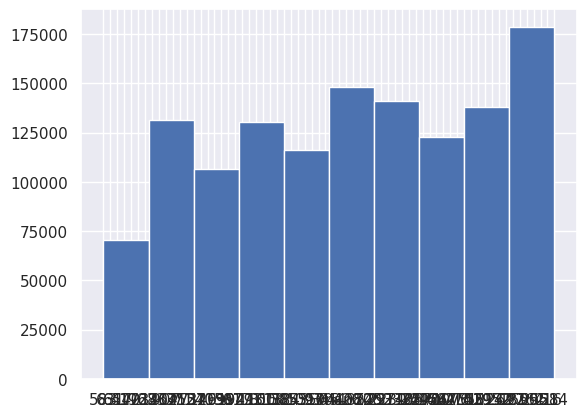

In [54]:
plt.hist(adata.obs['Relapse_followup'].astype('str'))

(array([ 70312., 131403., 106742., 130206., 116136., 147893., 141001.,
        122544., 138058., 178685.]),
 array([ 0. ,  6.5, 13. , 19.5, 26. , 32.5, 39. , 45.5, 52. , 58.5, 65. ]),
 <BarContainer object of 10 artists>)

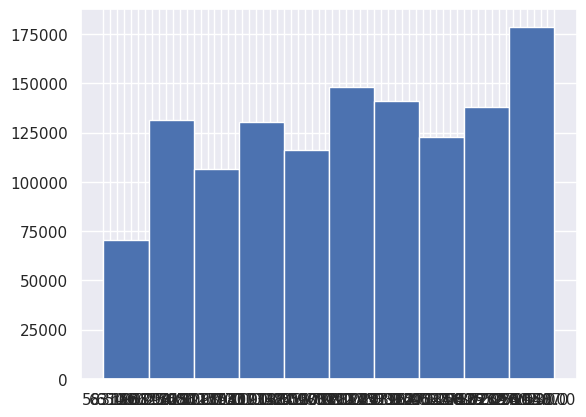

In [58]:
plt.hist(adata.obs['Surv_Followup'].astype('str'))

In [126]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'

In [127]:
bdata = pd.DataFrame
bdata = adata.obs[['Image','Object ID','CT_final','CT_basetumour']]
bdata[(bdata.Image.isin(['TMA_A']))].to_csv('tma_a.csv')
bdata[(bdata.Image.isin(['TMA_B']))].to_csv('tma_b.csv')

In [11]:
set(adata.obs.tumour_nontumour)

{'Nontumour', 'Tumour'}

In [129]:
df = adata.obs[adata.obs['tregion'].isin(['Stroma'])] 
df =  df[df['tumour_nontumour'].isin(['Tumour'])]

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/temp/9432438/ipykernel_3838539/716529442.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


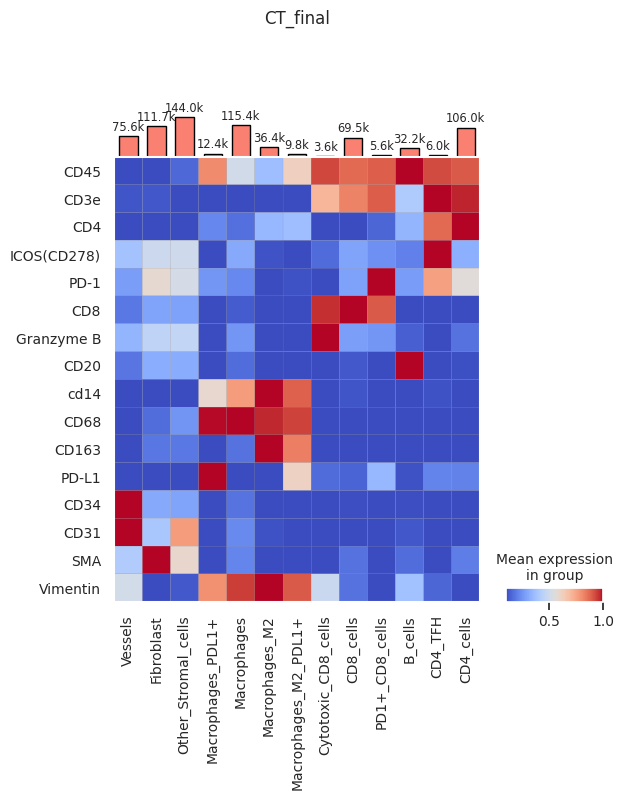

In [10]:
adata = ad.read_h5ad('adjtma_celltyped_final.h5ad')
adata = adata[adata.obs['tumour_nontumour'].isin(['Nontumour'])].copy()
stromalcells = ['CD45','CD3e','CD4','ICOS(CD278)','PD-1', 'CD8','Granzyme B','CD20', 'cd14','CD68','CD163', 'PD-L1', 'CD34', 'CD31','SMA', 'Vimentin']
adata = adata[:,adata.var_names.isin(stromalcells)].copy()
adata.var_names

def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

sc.pl.matrixplot(adata, var_names= stromalcells, groupby='CT_final', dendrogram=True,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'CT_final', return_fig=True).add_totals().savefig('CT_final.svg')


/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/temp/9432438/ipykernel_3838539/2838340419.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


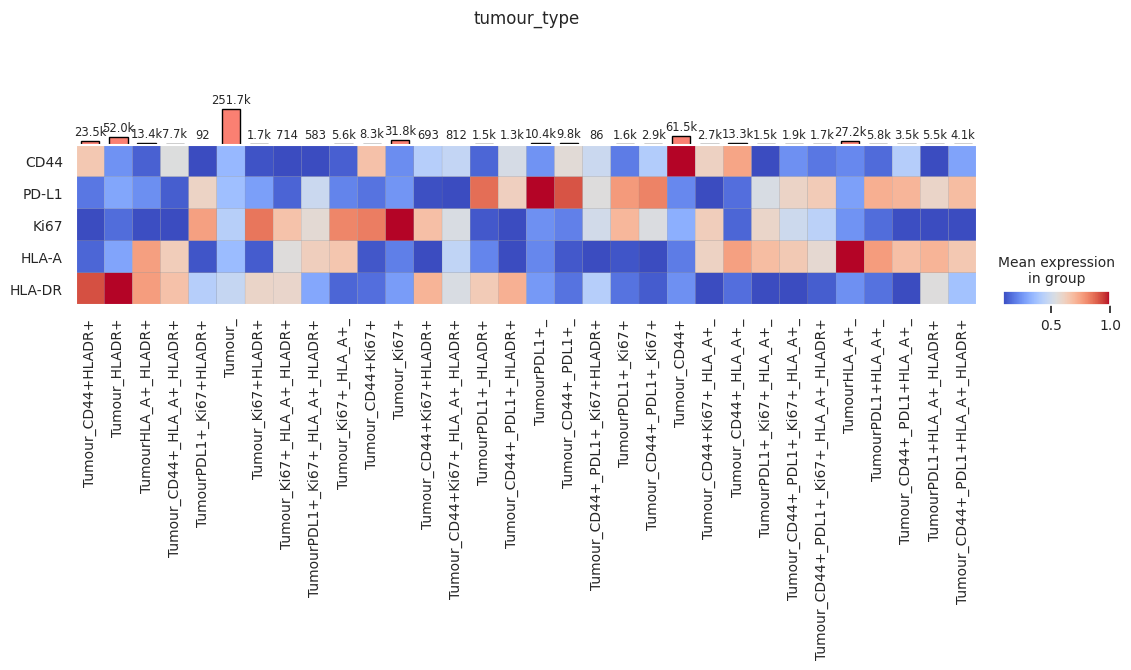

In [12]:
adata = ad.read_h5ad('adjtma_celltyped_final.h5ad')
adata = adata[adata.obs['tumour_nontumour'].isin(['Tumour'])].copy()
tumourcells= ['CD44', 'PD-L1', 'Ki67','HLA-A','HLA-DR']
adata = adata[:,adata.var_names.isin(tumourcells)].copy()
adata.var_names

def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

sc.pl.matrixplot(adata, var_names= tumourcells, groupby='Tumour_type', dendrogram=True,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'tumour_type', return_fig=True).add_totals().savefig('tumour_type_raw.svg')

/scratch/project_mnt/S0147/software/PCF_pipeline/envs/pcf/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/temp/9432438/ipykernel_3838539/769883326.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata= adata1.concatenate(adata2)


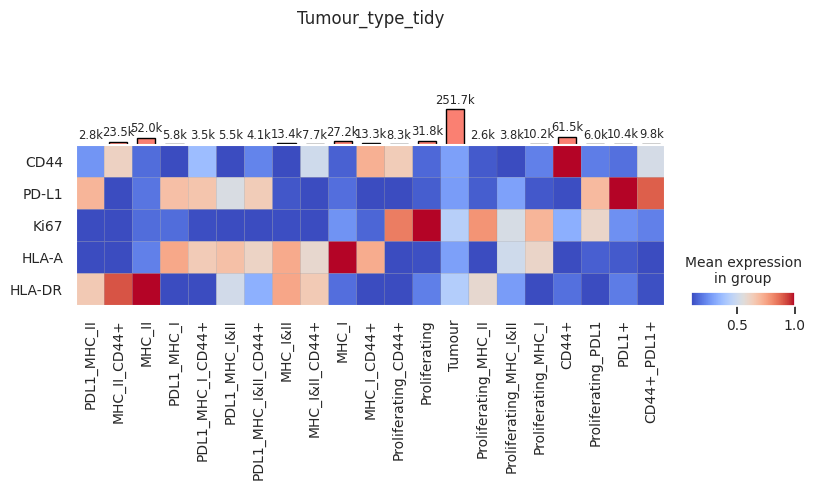

In [13]:
adata = ad.read_h5ad('adjtma_celltyped_final.h5ad')
adata = adata[adata.obs['tumour_nontumour'].isin(['Tumour'])].copy()
tumourcells= ['CD44', 'PD-L1', 'Ki67','HLA-A','HLA-DR']
adata = adata[:,adata.var_names.isin(tumourcells)].copy()
adata.var_names

def _percentile_transform(X, percentile, axis):
            X = np.nan_to_num(X, 0)   
            min_val_per_axis = np.min(X, axis=axis)
            percentile_val_per_axis = np.percentile(X, percentile, axis=axis)
            # Below will return divide by 0 runtime error if trying to normalise a column with all 0s,
            # to skip that, we replace the 0s with 1s, and then divide by 1s, which is the same as not dividing.
            denominator = percentile_val_per_axis - min_val_per_axis
            if np.any(denominator == 0):
                denominator[denominator == 0] = 1
            normalised_X = (X - min_val_per_axis) / denominator
            return normalised_X
    
    

adata1 = adata[adata.obs.Image.isin(['TMA_A'])].copy()
adata2 = adata[adata.obs.Image.isin(['TMA_B'])].copy()

pm.tl.normalize_arcsinh(adata1, cofactor=150, inplace=True)
pm.tl.normalize_arcsinh(adata2, cofactor=150, inplace=True)
adata1.X = _percentile_transform(adata1.X, 97, axis=0)
adata2.X = _percentile_transform(adata2.X, 97, axis=0)


sc.pp.scale(adata1)
sc.pp.scale(adata2)

adata1.X = stats.zscore(adata1.X,axis=1)
adata2.X = stats.zscore(adata2.X,axis=1)

adata= adata1.concatenate(adata2)

sc.pl.matrixplot(adata, var_names= tumourcells, groupby='Tumour_type_tidy', dendrogram=True,
                 use_raw=False, cmap="coolwarm", standard_scale='var', vmin = 0.1,
                 swap_axes= True,
                 title = 'Tumour_type_tidy', return_fig=True).add_totals().savefig('tumour_type.svg')

In [14]:
pwd

'/scratch/project_mnt/S0147/users/jamesm/jm_pcf_projects/adjtma_v1/celltyping_v2'